# Magnimind Mentorship Capstone Project:
Predicting MLB Hall of Fame Selection

In this project, I analyzed a dataset of 1215 Major League Baseball pitchers and attempted to predict whether each one has been named to the National Baseball Hall of Fame. 

Two criteria have been applied: the pitcher must have thrown a minimum of 1000 career innings (to ensure longevity), and must have retired no later than 2019 (to account for the time delay in eligibility). 

This dataset is highly imbalanced - just 82 of the 1215 pitchers are in the Hall of Fame.

I will use (six? seven?) models.

I used GridSearchCV to optimize models.

All models used K-Fold Cross Validation to generate a prediction for every player. I also include the probability for each prediction (or the best equivalent possible). This allows for more comprehensive aggregation and comparison across models - for example, which players were mostly consistently predicted incorrectly, and which features are correlated to higher errors. Furthermore, I also manually an adjusted prediction score to compare confidence with actual results.

# Data source and background

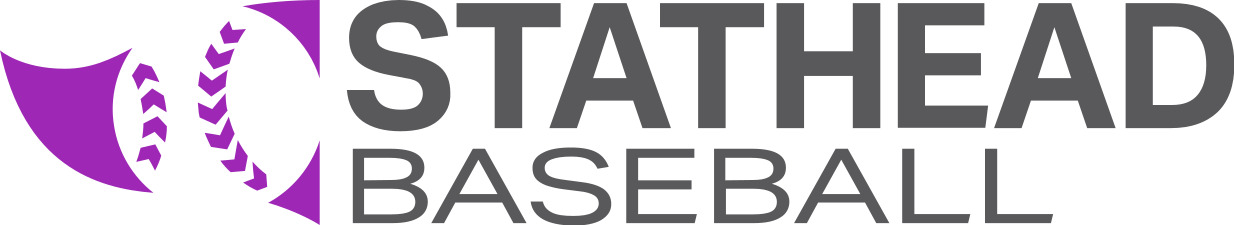

Stathead Baseball contains detailed statistics on all levels of professional and college baseball stretching as far back as 1871, including full play-by-play data on all MLB games since 1952.

(Parent company Sports Reference also operates Basketball Reference, Pro Football Reference, and many others)

Data challenges:

There is some dispute as to what qualifies as a Major League, especially pre-1901. Some accepted modern teams were previously in leagues that have since disbanded, and some legendary players spent part or all of their careers with teams that no longer exist. I used every league that Stathead judges to be major.

Older data are incomplete, especially for the Negro Leagues, where many barnstorming games were played for which there is little or no information available.

**Most importantly:** Hall of Fame induction is not based exclusively on objective statistics, but is voted on by the Baseball Writers' Association of America (BBWAA), whose motivations are often opaque and shift over time. Some players with impressive statistics are excluded for non-statistical reasons, such as admitted or suspected steroid usage. It has also been implied that personality factors and teams played for may have influenced voting decisions.

Additionally, some players with unimpressive playing careers may later achieve notoriety through coaching or management, and be inducted for those achievements.

Data Cleaning:

The dataset was relatively clean to begin with, however, you do have to be careful in how you sort data when creating the CSV, or it will break up data of players who played for multiple teams.

There were a handful of nulls as a result of some statistical factors simply never occuring for certain players. I filled these with 0.

A handful of players share a name with others. Thankfully, Stathead also includes a 'Player-additional' column with a unique identifying code for each player. I used this to disambiguate names.

To add the 'Hall of Fame' column, I had to use a separate filter to access a list of Hall of Famers and match them to the larger dataset.

Overall observations:

There is little real-world harm to be done with an incorrect prediction, as there are no health or legal implications. Therefore, in theory, Precision and Recall should be equally important, and for this reason I initially used F1 scoring in my GridSearchCVs. However, Recall was consistently the biggest struggle, so I also optimized models for Recall.

# Future Improvements and Ideas

After compiling prediction scores for each player, I want to try dropping the players about whom the models were most consistently wrong, and see if the models improve. Is it possible instead that the models overfit to these unlikely inclusions or exclusions?

Note about eligibility:

A player becomes eligible for the Hall of Fame five years after retiring. However, since induction does not take place until the year after voting, the delay is in practice 6 years, which is why 2019 is used as the cutoff.

Players who have retired more recently have had less time eligible, and thus may not be in the Hall of Fame yet even if they make it in the future. I am considering adding a column listing the years elapsed from eligibility to induction. But there are two complications with this:
1. A higher number may confuse the model.
2. A player may also become eligible six months after dying, which means I would have to add that data to my dataset, and my calculation for eligibility would have to account for this.